In [13]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Avoid Qt & font issues on headless Linux
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

In [14]:
# FX market parameters
S0 = 1.0800          # Current EUR/USD spot
sigma_annual = 0.085 # Annualized volatility
t = 1/12             # Horizon: 1 month (in years)
mu = 0.00            # Annual drift / trend
n_sim = 10000        # Number of simulations

# Decision thresholds
level_low = 1.0650   # Below: better FX rate / lower cost
level_high = 1.1000  # Above: exceeds budget

# Fixed seed → reproducible results for debugging
np.random.seed(42)

In [15]:
# Geometric Brownian Motion (standard for FX)
Z = np.random.normal(loc=0, scale=1, size=n_sim)
S_T = S0 * np.exp( (mu - 0.5 * sigma_annual**2) * t
                  + sigma_annual * np.sqrt(t) * Z )

# Summary statistics
mean_val = np.mean(S_T)
prob_below = np.mean(S_T < level_low)
prob_above = np.mean(S_T > level_high)
p5 = np.percentile(S_T, 5)
p95 = np.percentile(S_T, 95)

In [16]:
summary = pd.DataFrame([
    ["Mean", f"{mean_val:.4f}"],
    ["Median", f"{np.median(S_T):.4f}"],
    ["5th percentile", f"{p5:.4f}"],
    ["95th percentile", f"{p95:.4f}"],
    ["P < 1.0650", f"{prob_below:.1%}"],
    ["P > 1.1000", f"{prob_above:.1%}"],
    ["90% interval", f"[{p5:.4f}, {p95:.4f}]"]
], columns=["Metric", "Value"])

display(summary)

,Metric,Value
0,Mean,1.0799
1,Median,1.0796
2,5th percentile,1.0367
3,95th percentile,1.1241
4,P < 1.0650,28.9%
5,P > 1.1000,22.0%
6,90% interval,"[1.0367, 1.1241]"


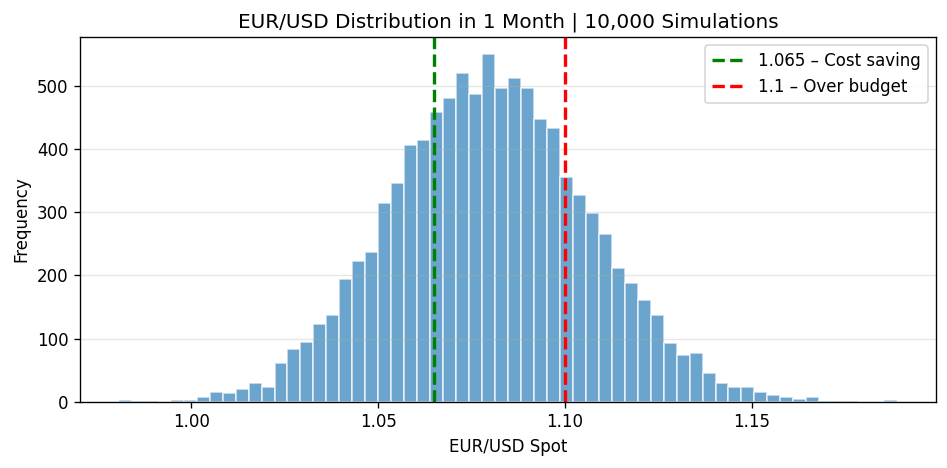

In [17]:
plt.figure(figsize=(8, 4))
plt.hist(S_T, bins=60, alpha=0.7, color='#2c7fb8', edgecolor='white')

plt.axvline(level_low, color='green', ls='--', lw=2, label=f'{level_low} – Cost saving')
plt.axvline(level_high, color='red', ls='--', lw=2, label=f'{level_high} – Over budget')

plt.title(f'EUR/USD Distribution in 1 Month | {n_sim:,} Simulations', fontsize=12)
plt.xlabel('EUR/USD Spot')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()